In [718]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.special import jn_zeros

In [719]:
geometry = "circle"

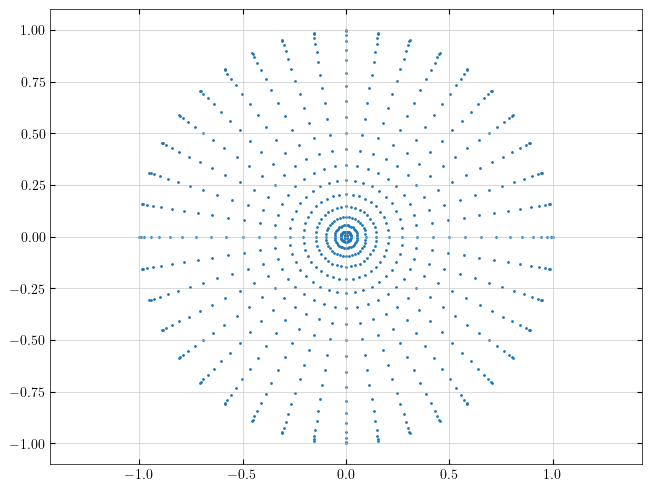

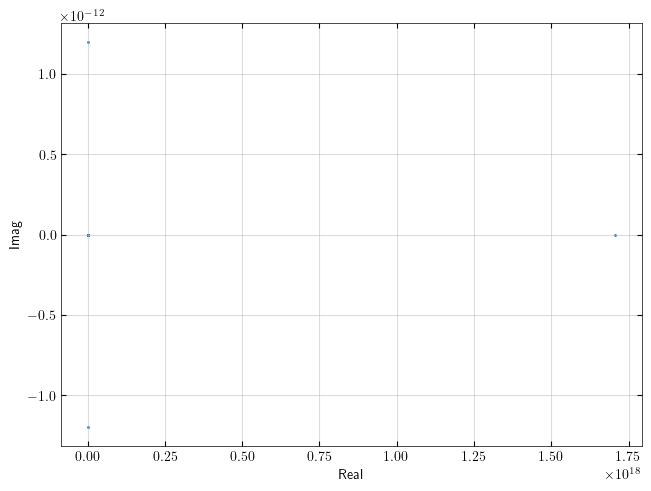

(840, 840)
[  8.08662458   8.08669346  16.06095859  16.06096473  27.43728411
  27.43728424  35.46621983  35.46641604  41.64986022  41.64986022
  51.89411463  51.89411965  58.46105274  58.46105274  72.72298628
  72.722987    77.99202435  77.99202435  82.42488577  82.42518317
  96.83343686  96.83343686 107.46919282 107.46929463 117.66028277
 117.66028277 123.8066344  123.8066344  137.69581539 137.69581754
 149.00229891 149.00256676 153.83271628 153.83271628 154.02667828
 154.02667828 171.55159354 171.55159354 172.8940753  172.8940753
 182.78623597 182.78631212 203.07193589 203.07193589 208.43485128
 208.43485128 212.14797217 212.14797217 222.39528562 222.3952909 ]


In [720]:
x = np.loadtxt(f"../results/{geometry}_x.csv")
y = np.loadtxt(f"../results/{geometry}_y.csv")
plt.scatter(x, y, s=1)
plt.axis('equal')
plt.show()

plt.figure()
plt.scatter(eigval_real, eigval_imag, s=1)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.show()

eigval_real = np.loadtxt(f"../results/{geometry}_eigval_real.csv")
eigval_imag = np.loadtxt(f"../results/{geometry}_eigval_imag.csv")
eigvec_real = np.loadtxt(f"../results/{geometry}_eigvec_real.csv", delimiter=",")
eigvec_imag = np.loadtxt(f"../results/{geometry}_eigvec_imag.csv", delimiter=",")

eigval = eigval_real + 1j*eigval_imag

if np.all(eigval_imag == 0):
    eigval = np.real(eigval)
    print("All eigenvalues real!")

eigvec = eigvec_real + 1j*eigvec_imag
amplitude = np.abs(eigvec)**2
print(eigvec.shape)

eigval_abs = np.abs(eigval)
idx = np.argsort(eigval_abs)
eigval_abs_sort = eigval_abs[idx]
eigvec_sort = eigvec[:, idx]
amplitude_sort = amplitude[:, idx]
print(eigval_abs_sort[:50])

In [721]:
try: 
    A = np.loadtxt("../A.csv", delimiter = ",")
    B = np.loadtxt("../B.csv", delimiter = ",")
    print(A.shape)
    if A.shape[0] < 100:
        for row in A:
            print("".join("#" if x != 0 else "." for x in row))
            #print("".join(f"{x:.2f} " for x in row))

except:
    pass

print(f"Matrix A sparsity: {100*np.sum(A==0)/np.size(A):.4f}%")
print(f"Matrix B sparsity: {100*np.sum(B==0)/np.size(B):.4f}%")

(840, 840)
Matrix A sparsity: 93.4038%
Matrix B sparsity: 99.8921%


In [713]:
if geometry == "square":
    L_x = max(x) - min(x)
    L_y = max(y) - min(y)
    exact = np.pi**2 * np.sort(np.array([(i/L_x)**2 + (j/L_y)**2 
                  for i in range(1, 100) for j in range(1, 100)]))
elif geometry == "semicircle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(1, 100)]))
elif geometry == "circle":
    exact = np.sort(np.ravel([jn_zeros(n, 100)**2 for n in range(0, 100) for polarization in ["x", "y"]]))

exact = exact[:len(eigval_abs_sort)]

rel_error = (eigval_abs_sort - exact) / exact

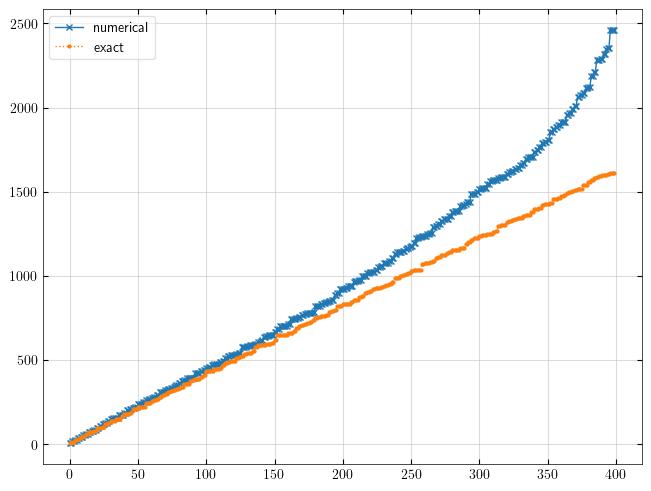

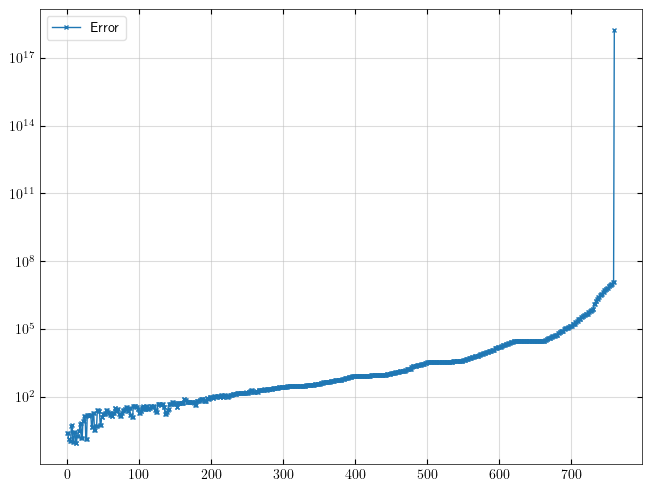

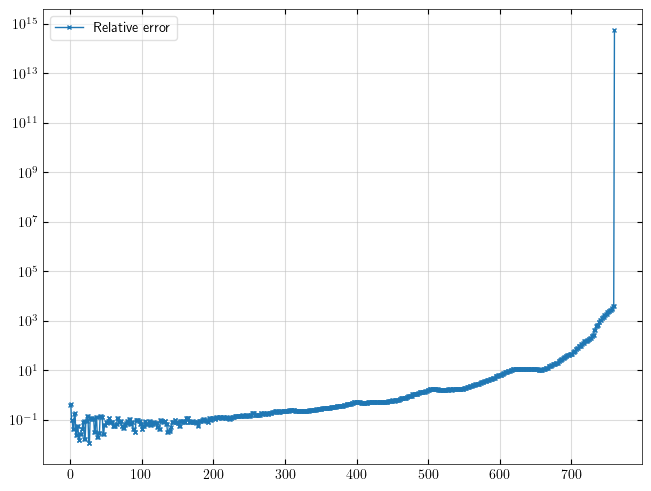

In [714]:
xlim = 400 #len(eigval_abs)//3
plt.figure()
plt.plot(eigval_abs_sort[:xlim], marker='x', markersize=5, linewidth=1, label = "numerical")
plt.plot(exact[:xlim], marker = 'o', markersize = 2, linewidth=1, linestyle = ":", label = "exact")
plt.legend()

plt.figure()
plt.plot(eigval_abs_sort - exact, marker='x', markersize=3, linewidth=1, label = 'Error')
plt.yscale('log')
plt.legend()

plt.figure()
plt.plot(rel_error, marker='x', markersize=3, linewidth=1, label = 'Relative error')
plt.yscale('log')
plt.legend()

plt.show()

In [715]:
def plot_interpolated(x, y, z):
    
    xi = np.linspace(min(x), max(x), 500)
    yi = np.linspace(min(y), max(y), 500)
    X_grid, Y_grid = np.meshgrid(xi, yi)
    
    Z = griddata(
        (x, y),
        z,
        (X_grid, Y_grid),
        method='cubic'
    )
    
    plt.contourf(X_grid, Y_grid, Z, levels=20)
    plt.colorbar(label='Amplitude')
    plt.scatter(x, y, c='k', alpha = 0.5, s=1) # Show actual data points
    

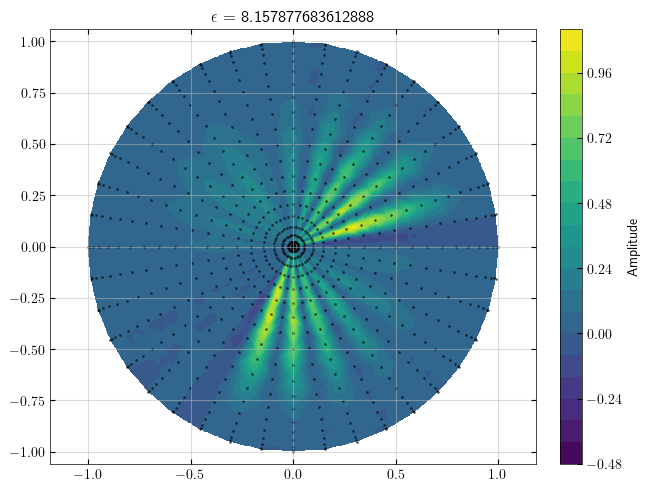

In [717]:
i = 0
psi2 = amplitude_sort[:,i]

plot_interpolated(x, y, psi2)
plt.title(rf"$\epsilon$ = {eigval_abs_sort[i]}")
plt.axis('equal')
plt.show()